# DBSCAN Algorithm in Machine Learning

## What is DBSCAN?

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** is a clustering algorithm used in Machine Learning. It groups together data points that are closely packed and marks points that lie alone in low-density regions as **noise (outliers)**.

Unlike some clustering algorithms, DBSCAN does **not require the number of clusters to be specified beforehand**.

---

## Key Idea

DBSCAN identifies clusters based on the **density of data points**. Areas with a high concentration of points are considered clusters, while areas with low density are treated as noise.

---

## Important Parameters

### 1. Epsilon (ε)
- The maximum distance between two points for them to be considered neighbors.

### 2. MinPts
- The minimum number of points required to form a dense region.

---

## Types of Points in DBSCAN

### Core Point
A point that has at least **MinPts neighbors within the distance ε**.

### Border Point
A point that is within the neighborhood of a core point but does not have enough neighbors to be a core point.

### Noise Point
A point that does not belong to any cluster and is considered an **outlier**.

---

## Advantages of DBSCAN

- Can find **clusters of arbitrary shape**
- **No need to specify the number of clusters**
- Can **detect outliers automatically**

---

## Limitations

- Choosing the correct **ε (epsilon)** and **MinPts** can be difficult.
- Performance decreases when clusters have **different densities**.

---

## Applications

- Customer segmentation
- Image segmentation
- Anomaly detection
- Geographic data clustering

---

## Comparison with K-Means

| Feature | DBSCAN | K-Means |
|------|------|------|
| Number of clusters needed | No | Yes |
| Detects outliers | Yes | No |
| Cluster shape | Arbitrary | Mostly spherical |
| Sensitivity to noise | Low | High |

---

## Summary

DBSCAN is a powerful clustering algorithm that groups data based on density. It is particularly useful when dealing with noisy data and when the number of clusters is not known beforehand.

## Cluster Expansion in DBSCAN

In DBSCAN, clusters **gradually expand** from dense regions of data.

### How Expansion Happens

1. The algorithm selects an **unvisited point**.
2. It finds all points within a distance **ε (epsilon)** from that point.
3. If the number of neighbors is **greater than or equal to MinPts**, the point becomes a **Core Point**.
4. A **new cluster is created**.
5. All neighboring points are added to the cluster.
6. For each of those neighbors, the algorithm again searches for their neighbors within **ε**.
7. If those points also satisfy the density condition, the **cluster keeps expanding**.

### Key Idea

The cluster grows **step-by-step through connected dense regions** until no more nearby dense points are found.

### Simple Intuition

You can think of the cluster growing like **spreading ink on paper**:
- Start from one dense point
- Spread to nearby dense points
- Continue spreading until the density becomes low

### Result

- **Dense connected points → Cluster**
- **Points far from clusters → Noise (Outliers)**

#### Comparing  different unsupervised models on few datasets: 

In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [4]:
blobs = pd.read_csv('cluster_blobs.csv')
blobs.head(5)

,X1,X2
0,4.645333,6.822294
1,4.784032,6.422883
2,-5.851786,5.774331
3,-7.459592,6.456415
4,4.918911,6.961479


<Axes: xlabel='X1', ylabel='X2'>

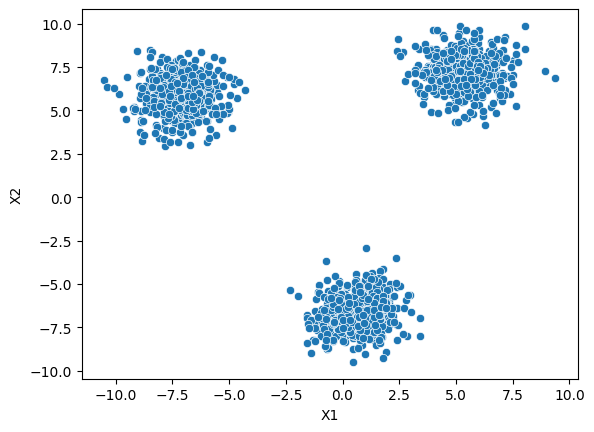

In [5]:
sns.scatterplot(data= blobs, x = 'X1', y = 'X2')

* Here X1 and X2 are two features, this dataset is unlabeled.

In [7]:
moons = pd.read_csv('cluster_moons.csv')
moons.head()

,X1,X2
0,0.674362,-0.444625
1,1.547129,-0.239796
2,1.601930,-0.230792
3,0.014563,0.449752
4,1.503476,-0.389164


<Axes: xlabel='X1', ylabel='X2'>

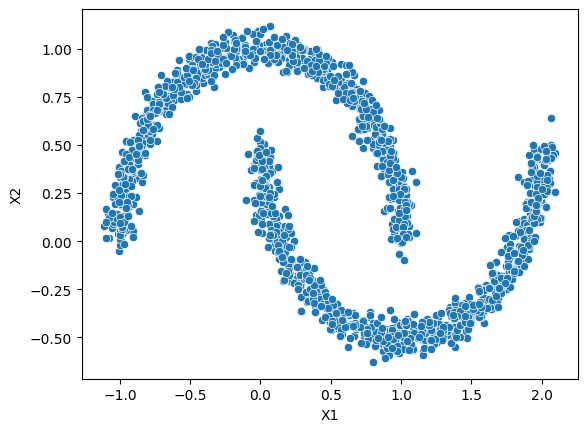

In [8]:
sns.scatterplot(data = moons, x = 'X1', y = 'X2')

In [9]:
circles = pd.read_csv('cluster_circles.csv')
circles.head()

,X1,X2
0,-0.348677,0.010157
1,-0.176587,-0.954283
2,0.301703,-0.113045
3,-0.782889,-0.719468
4,-0.733280,-0.757354


<Axes: xlabel='X1', ylabel='X2'>

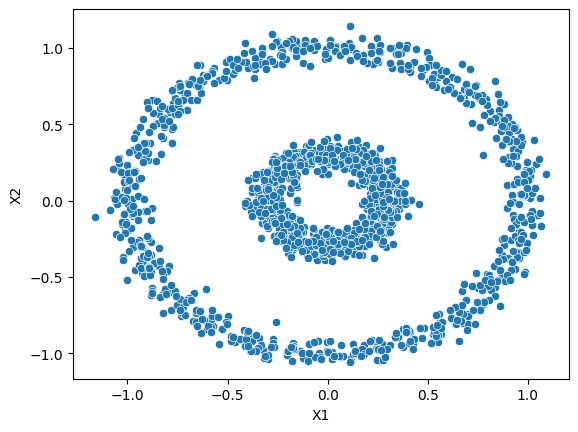

In [10]:
sns.scatterplot(data = circles, x = 'X1', y = 'X2')

##### Label Discovery:

In [12]:
def display_category(model, data):
    labels = model.fit_predict(data)
    sns.scatterplot(data = data, x = 'X1', y ='X2', hue = labels, palette = 'Set2') 

#### kMeans algorithm results:
* It uses distance as a metrics.

In [16]:
from sklearn.cluster import KMeans

In [17]:
model = KMeans(n_clusters=2)

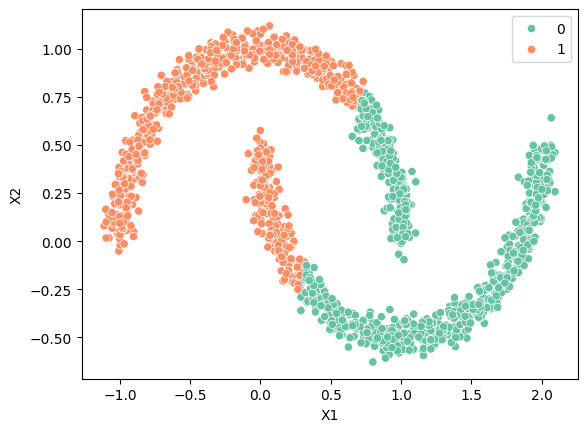

In [18]:
display_category(model, moons)

* KMeans is not good for above dataset

In [19]:
model = KMeans(n_clusters=3)

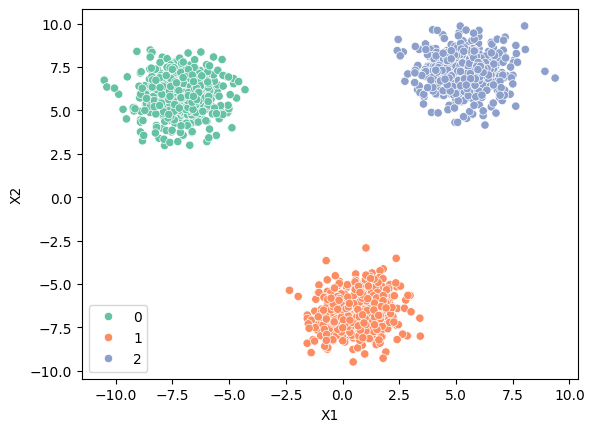

In [21]:
display_category(model, blobs)

* KMeans is good for above data set

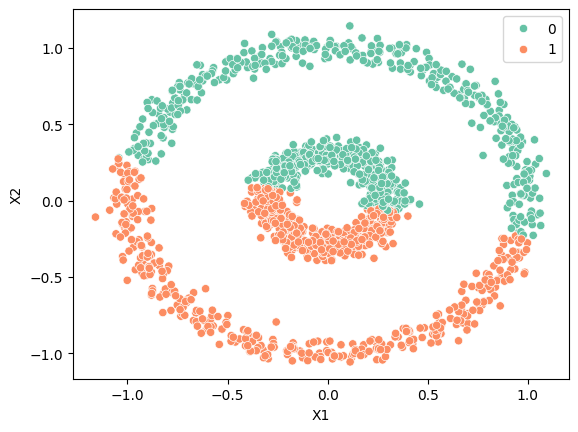

In [22]:
model = KMeans(n_clusters=2)
display_category(model, circles)

* KMeans is not good for above data set

###  DBSACN:

In [23]:
from sklearn.cluster import DBSCAN

In [24]:
db_model = DBSCAN(eps=0.6)

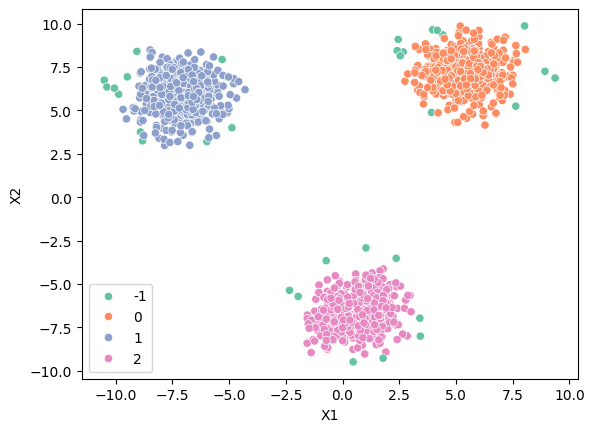

In [25]:
display_category(db_model, blobs)

* DBSACN identifies three clusters and outliers for above dataset. 

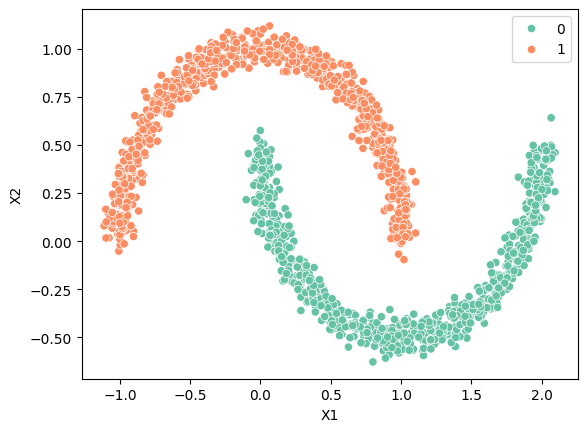

In [29]:
model = DBSCAN(eps = 0.2)
display_category(model, moons)

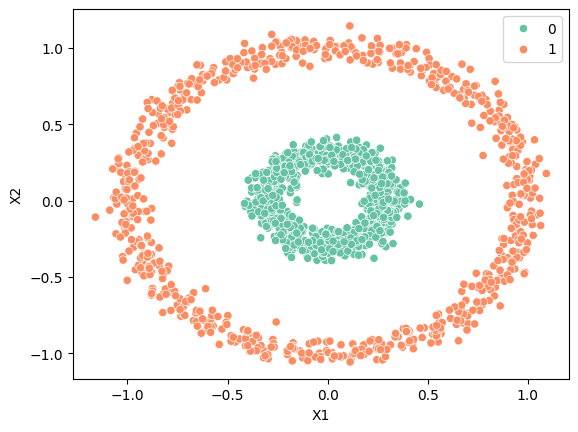

In [30]:
model = DBSCAN(eps = 0.2)
display_category(model, circles)

* From above all it seems that DBSACN Algrithm is good. 